In [1]:
path = "C:\\Users\\senas\\Downloads" # Buraya kendi gerçek yolunu yaz

In [2]:
import pandas as pd
import glob
import os

# "01_2025.xlsx" formatındaki tüm dosyaları bulur
files = glob.glob(os.path.join(path, "*_202*.xlsx"))

files = [f for f in files if "osf_2193681000" not in f]

# 2. İşlemi yapacak fonksiyonu tanımla
def process_energy_data(file_path):
    # Dosyayı oku
    df = pd.read_excel(file_path)

    # Maskeleme ve Kaydırma (Shift) işlemi
    mask = df["Unnamed: 1"] == "Çekiş"
    if "Saat/Gün" in df.columns:
        df.loc[mask, "Saat/Gün"] = df["Saat/Gün"].shift(1)

    # İlk satırı düşür ve indeksi sıfırla
    df = df.drop(index=0).reset_index(drop=True)

    # Sütun adını değiştir
    df.rename(columns={"Unnamed: 1": "Veriş/Çekiş"}, inplace=True)

    return df

# 3. Tüm dosyaları dön ve sözlükte veya listede sakla
all_data = {}

for f in files:
    file_name = os.path.basename(f)
    print(f"{file_name} işleniyor...")
    all_data[file_name] = process_energy_data(f)

# Örnek: Şubat 2025 verisine ulaşmak için:
# all_data["02_2025.xlsx"].head()

01_2025.xlsx işleniyor...
01_2026.xlsx işleniyor...
02_2025.xlsx işleniyor...
02_2026.xlsx işleniyor...
03_2025.xlsx işleniyor...
04_2025.xlsx işleniyor...
05_2025.xlsx işleniyor...
06_2025.xlsx işleniyor...
07_2025.xlsx işleniyor...
08_2025.xlsx işleniyor...
09_2025.xlsx işleniyor...
10_2025.xlsx işleniyor...
11_2025.xlsx işleniyor...
12_2025.xlsx işleniyor...


In [3]:
merged = []

for file_name, df in all_data.items():

    month = int(file_name[:2])
    year = int(file_name[3:7])

    temp = df.copy()
    temp["month_file"] = month
    temp["year_file"] = year

    merged.append(temp)

df_all = pd.concat(merged, ignore_index=True)

print(df_all.shape)
df_all.head()

(700, 36)


,Saat/Gün,Veriş/Çekiş,1,2,3,4,5,6,7,8,...,25,26,27,28,29,30,31,Toplam,month_file,year_file
0,00-01,Veriş,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,1,2025
1,00-01,Çekiş,6.706,6.834,6.737,6.715,6.717,6.735,6.779,6.792,...,7.092,7.211,7.305,7.134,7.088,7.142,7.21,213.021,1,2025
2,01-02,Veriş,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,1,2025
3,01-02,Çekiş,6.770,6.894,6.827,6.789,6.828,6.830,6.853,6.888,...,7.155,7.315,7.297,7.207,7.180,7.215,7.26,215.081,1,2025
4,02-03,Veriş,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,1,2025


In [4]:
df_all = df_all[df_all["Veriş/Çekiş"] == "Çekiş"].copy()

In [5]:
df_all["consumption"] = pd.to_numeric(df_all.iloc[:, -3], errors="coerce")

In [6]:
print(df_all["Saat/Gün"].head(20))

1     00-01
3     01-02
5     02-03
7     03-04
9     04-05
11    05-06
13    06-07
15    07-08
17    08-09
19    09-10
21    10-11
23    11-12
25    12-13
27    13-14
29    14-15
31    15-16
33    16-17
35    17-18
37    18-19
39    19-20
Name: Saat/Gün, dtype: object


In [7]:
print(df_all["Saat/Gün"].sample(20))

575    12-13
505    02-03
7      03-04
111    05-06
501    00-01
529    14-15
419    09-10
185    17-18
535    17-18
677    13-14
625    12-13
243    21-22
645    22-23
483    16-17
513    06-07
647    23-24
667    08-09
463    06-07
127    13-14
219    09-10
Name: Saat/Gün, dtype: object


In [8]:
df_all = df_all[df_all["Saat/Gün"].astype(str).str.strip() != "Toplam"].copy()

In [9]:
print(df_all["Saat/Gün"].head(20))
print(df_all.shape)

1     00-01
3     01-02
5     02-03
7     03-04
9     04-05
11    05-06
13    06-07
15    07-08
17    08-09
19    09-10
21    10-11
23    11-12
25    12-13
27    13-14
29    14-15
31    15-16
33    16-17
35    17-18
37    18-19
39    19-20
Name: Saat/Gün, dtype: object
(336, 37)


In [10]:
print(df_all.columns.tolist())

['Saat/Gün', 'Veriş/Çekiş', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 'Toplam', 'month_file', 'year_file', 'consumption']


In [11]:
day_cols = [str(i) for i in range(1, 32)]

df_all.columns = df_all.columns.map(str)

long_df = df_all.melt(
    id_vars=["Saat/Gün", "Veriş/Çekiş", "month_file", "year_file"],
    value_vars=day_cols,
    var_name="day",
    value_name="cons_value"
)

print(long_df.head())
print(long_df.shape)

  Saat/Gün Veriş/Çekiş  month_file  year_file day  cons_value
0    00-01       Çekiş           1       2025   1       6.706
1    01-02       Çekiş           1       2025   1       6.770
2    02-03       Çekiş           1       2025   1       6.855
3    03-04       Çekiş           1       2025   1       6.915
4    04-05       Çekiş           1       2025   1       6.964
(10416, 6)


In [12]:
long_df = long_df[long_df["Veriş/Çekiş"].astype(str).str.strip() == "Çekiş"].copy()

long_df["cons_value"] = pd.to_numeric(long_df["cons_value"], errors="coerce")
long_df["day"] = pd.to_numeric(long_df["day"], errors="coerce")

long_df = long_df.dropna(subset=["cons_value", "day"]).copy()

print(long_df.head())
print(long_df.shape)

  Saat/Gün Veriş/Çekiş  month_file  year_file  day  cons_value
0    00-01       Çekiş           1       2025    1       6.706
1    01-02       Çekiş           1       2025    1       6.770
2    02-03       Çekiş           1       2025    1       6.855
3    03-04       Çekiş           1       2025    1       6.915
4    04-05       Çekiş           1       2025    1       6.964
(9780, 6)


In [13]:
long_df["hour"] = pd.to_numeric(
    long_df["Saat/Gün"].astype(str).str.extract(r'^(\d{2})-')[0],
    errors="coerce"
)

print(long_df[["Saat/Gün", "hour"]].head(20))
print("hour NaN sayısı:", long_df["hour"].isna().sum())

   Saat/Gün  hour
0     00-01     0
1     01-02     1
2     02-03     2
3     03-04     3
4     04-05     4
5     05-06     5
6     06-07     6
7     07-08     7
8     08-09     8
9     09-10     9
10    10-11    10
11    11-12    11
12    12-13    12
13    13-14    13
14    14-15    14
15    15-16    15
16    16-17    16
17    17-18    17
18    18-19    18
19    19-20    19
hour NaN sayısı: 0


In [14]:
long_df["timestamp"] = pd.to_datetime(
    dict(
        year=long_df["year_file"],
        month=long_df["month_file"],
        day=long_df["day"].astype(int),
        hour=long_df["hour"].astype(int)
    ),
    errors="coerce"
)

print("timestamp NaN sayısı:", long_df["timestamp"].isna().sum())
print(long_df[["timestamp", "cons_value"]].head())

timestamp NaN sayısı: 0
            timestamp  cons_value
0 2025-01-01 00:00:00       6.706
1 2025-01-01 01:00:00       6.770
2 2025-01-01 02:00:00       6.855
3 2025-01-01 03:00:00       6.915
4 2025-01-01 04:00:00       6.964


In [15]:
long_df = long_df.dropna(subset=["timestamp"]).copy()

print(long_df.shape)
print(long_df[["timestamp", "cons_value"]].head())

(9780, 8)
            timestamp  cons_value
0 2025-01-01 00:00:00       6.706
1 2025-01-01 01:00:00       6.770
2 2025-01-01 02:00:00       6.855
3 2025-01-01 03:00:00       6.915
4 2025-01-01 04:00:00       6.964


In [16]:
ts_df = long_df[["timestamp", "cons_value"]].copy()
ts_df = ts_df.rename(columns={"cons_value": "consumption"})
ts_df = ts_df.sort_values("timestamp").drop_duplicates(subset="timestamp")
ts_df = ts_df.set_index("timestamp")

# ── REINDEX EKLE ─────────────────────────────
full_index = pd.date_range(
    start=ts_df.index.min(),
    end=ts_df.index.max(),
    freq="h"
)
ts_df = ts_df.reindex(full_index)
ts_df.index.name = "timestamp"
# ─────────────────────────────────────────────

print(ts_df.head())
print(ts_df.shape)

                     consumption
timestamp                       
2025-01-01 00:00:00        6.706
2025-01-01 01:00:00        6.770
2025-01-01 02:00:00        6.855
2025-01-01 03:00:00        6.915
2025-01-01 04:00:00        6.964
(9802, 1)


In [17]:
ts_df["consumption"] = ts_df["consumption"].interpolate(method="time")
print("Eksik consumption:", ts_df["consumption"].isna().sum())

Eksik consumption: 0


In [18]:
import numpy as np

ts_df["hour"] = ts_df.index.hour
ts_df["dayofweek"] = ts_df.index.dayofweek
ts_df["month"] = ts_df.index.month

ts_df["hour_sin"] = np.sin(2 * np.pi * ts_df["hour"] / 24)
ts_df["hour_cos"] = np.cos(2 * np.pi * ts_df["hour"] / 24)

ts_df["lag24"] = ts_df["consumption"].shift(24)

ts_df = ts_df.dropna().copy()

print(ts_df.head())
print(ts_df.shape)

                     consumption  hour  dayofweek  month  hour_sin  hour_cos  \
timestamp                                                                      
2025-01-02 00:00:00        6.834     0          3      1  0.000000  1.000000   
2025-01-02 01:00:00        6.894     1          3      1  0.258819  0.965926   
2025-01-02 02:00:00        6.942     2          3      1  0.500000  0.866025   
2025-01-02 03:00:00        6.950     3          3      1  0.707107  0.707107   
2025-01-02 04:00:00        6.962     4          3      1  0.866025  0.500000   

                     lag24  
timestamp                   
2025-01-02 00:00:00  6.706  
2025-01-02 01:00:00  6.770  
2025-01-02 02:00:00  6.855  
2025-01-02 03:00:00  6.915  
2025-01-02 04:00:00  6.964  
(9778, 7)


In [19]:
train = ts_df[ts_df.index < "2025-12-01"].copy()
test = ts_df[ts_df.index >= "2025-12-01"].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (7992, 7)
Test shape: (1786, 7)


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = ["consumption", "hour_sin", "hour_cos", "dayofweek", "lag24"]

X_train = train[features]
X_test = test[features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = IsolationForest(
    contamination=0.03,
    n_estimators=200,
    random_state=42
)

model.fit(X_train_scaled)

test["pred"] = model.predict(X_test_scaled)
test["anomaly"] = (test["pred"] == -1).astype(int)

print("Test anomaly sayısı:", test["anomaly"].sum())
print("Test anomaly oranı:", test["anomaly"].mean())

Test anomaly sayısı: 138
Test anomaly oranı: 0.07726763717805152


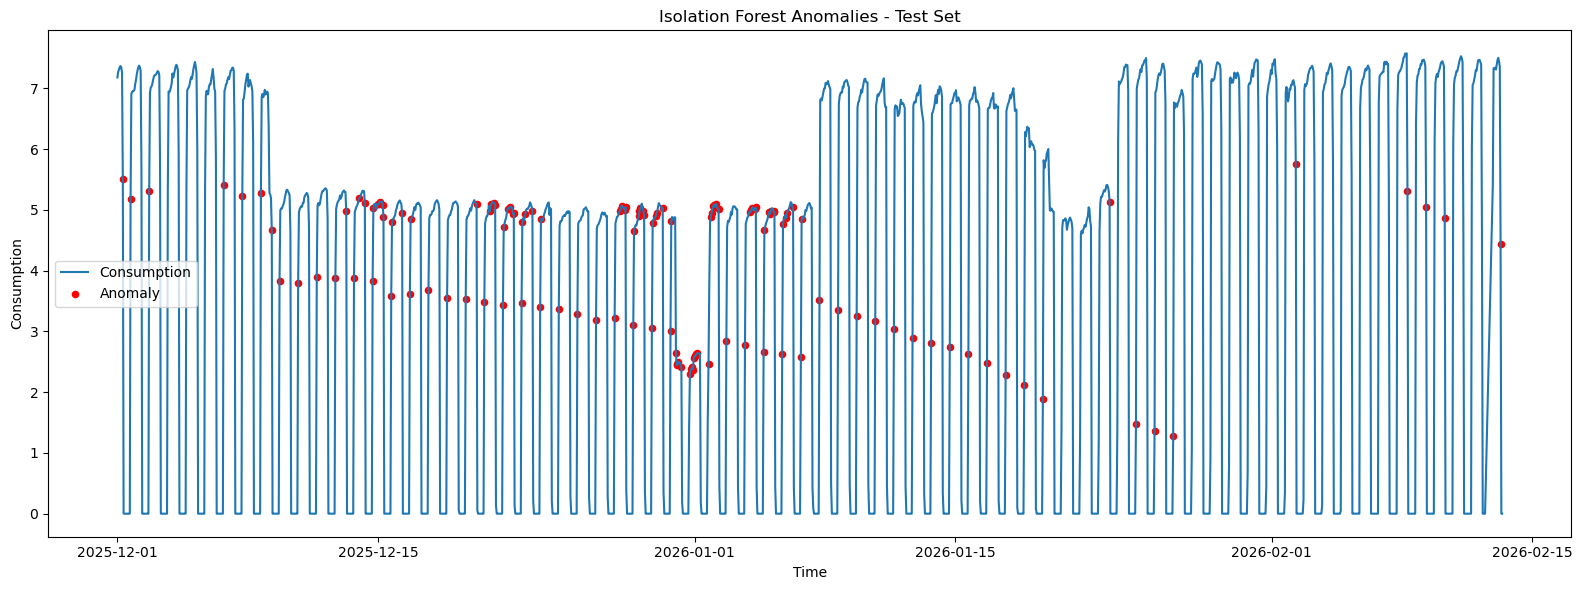

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.plot(test.index, test["consumption"], label="Consumption")
plt.scatter(
    test.index[test["anomaly"] == 1],
    test.loc[test["anomaly"] == 1, "consumption"],
    color="red",
    s=20,
    label="Anomaly"
)
plt.title("Isolation Forest Anomalies - Test Set")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.legend()
plt.tight_layout()
plt.show()

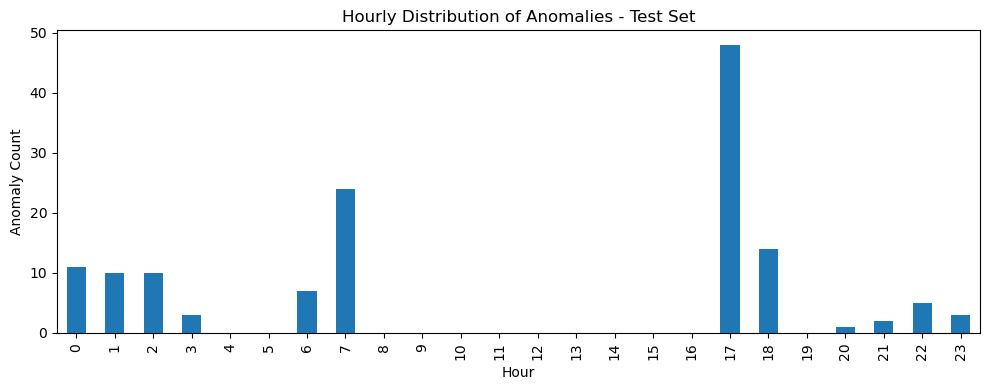

In [22]:
hourly_anomalies = test.groupby(test.index.hour)["anomaly"].sum()

plt.figure(figsize=(10,4))
hourly_anomalies.plot(kind="bar")
plt.title("Hourly Distribution of Anomalies - Test Set")
plt.xlabel("Hour")
plt.ylabel("Anomaly Count")
plt.tight_layout()
plt.show()

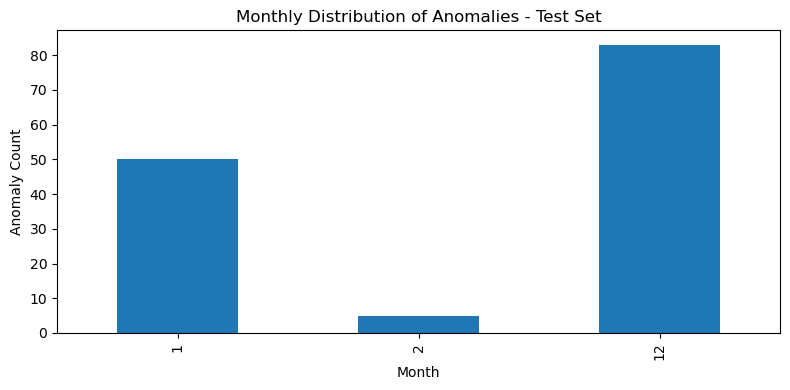

In [23]:
monthly_anomalies = test.groupby(test.index.month)["anomaly"].sum()

plt.figure(figsize=(8,4))
monthly_anomalies.plot(kind="bar")
plt.title("Monthly Distribution of Anomalies - Test Set")
plt.xlabel("Month")
plt.ylabel("Anomaly Count")
plt.tight_layout()
plt.show()

In [24]:
test.to_csv("test_anomaly_results.csv")
train.to_csv("train_anomaly_results.csv")